In [1]:
### data cleaning

import pandas as pd
import os
import numpy as np

folder_path = "Data"
files = os.listdir(folder_path)
datas = []  # master list of dfs

for file in files:  # save each file to master list
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        
        # read each CSV and keep only the first 400 ms (column indices 0–405)
        df = pd.read_csv(file_path).iloc[:, :406]

        # add column showing what neuron we are working on
        df['neuron'] = file[-7:-4]        # extract neuron ID from filename
        move = df.pop('neuron')           # move neuron column to front
        df.insert(0, 'neuron', move)

        # add to list
        datas.append(df)

# combine all neuron files
df = pd.concat(datas, axis=0, ignore_index=True)
print(df.shape)
df.head()

# compute weighted activation using sum of time-series values
weighted = pd.DataFrame({
    "activation_weight": df.iloc[:, 7:406].sum(axis=1)
})

# keep metadata columns + activation_weight
averaged_data = pd.concat([df.iloc[:, 0:7], weighted], axis=1)

# group by neuron, person, and orientation
grouped = averaged_data.groupby(
    ["neuron", "labels.person", "labels.orientation"],
    as_index=False
)["activation_weight"].sum()

# pivot so each row is (person, orientation) and each column is a neuron
cleaned = grouped.pivot_table(
    index=["labels.person", "labels.orientation"],
    columns="neuron",
    values="activation_weight"
)

cleaned.head()

(206216, 407)


neuron                             005  009   013  014  017  018   021   025  \
labels.person labels.orientation                                               
1             back                29.0  4.0  12.0  1.0  1.0  2.0  23.0  20.0   
              down                31.0  5.0  38.0  3.0  6.0  4.0   8.0  16.0   
              front               48.0  0.0  26.0  2.0  2.0  1.0   5.0  13.0   
              left 3/4            38.0  3.0  42.0  0.0  0.0  1.0  15.0  13.0   
              left profile        23.0  2.0  16.0  0.0  4.0  5.0  12.0  22.0   

neuron                            026   029  ...   401   402  405   409  413  \
labels.person labels.orientation             ...                               
1             back                1.0  24.0  ...   4.0   1.0  3.0  21.0  7.0   
              down                1.0  29.0  ...   6.0   6.0  1.0  11.0  9.0   
              front               0.0  32.0  ...  14.0  15.0  4.0  12.0  5.0   
              left 3/4            0.0  22.0  ...   6.0   5.0  3.0  32.0  5.0   
              left profile        1.0  31.0  ...   1.0   5.0  5.0  20.0  9.0   

neuron                            421   425   429  433   437  
labels.person labels.orientation                              
1             back                8.0   4.0   5.0  5.0  36.0  
              down                4.0  21.0  10.0  1.0  26.0  
              front               7.0   8.0   4.0  3.0  20.0  
              left 3/4            6.0  11.0   6.0  1.0  40.0  
              left profile        6.0   5.0   4.0  4.0  41.0  

[5 rows x 155 columns]

In [4]:
cleaned = cleaned.fillna(0)

# Explanation of Approach and Workflow

For this analysis, I wanted to investigate how neural activation data can predict the identity of individuals based on their responses. The dataset is high-dimensional (neurons × time points), so the first step was to reduce complexity and extract meaningful patterns.

1. **Dimensionality Reduction (PCA):**  
   - With 400+ time points per neuron, the feature space is very large and noisy.  
   - PCA was applied to extract the first 10 principal components, which capture ~37% of the total variance.  
   - This step reduces dimensionality, simplifies the dataset, and highlights the most important patterns in neural activity.  

2. **Regression and Classification Models:**  
   - **Linear and Ridge Regression:** Tested as baseline models for predicting continuous labels (activation patterns or responses). Ridge adds regularization to handle multicollinearity. Both models performed similarly, indicating limited linear predictability.  
   - **Logistic Regression & Ridge Classifier:** Chosen for classification of person labels because they handle multi-class problems and work well with linearly separable PCA features. Logistic Regression performed best, suggesting some linear structure in the reduced data.  
   - **Decision Tree & Random Forest:** Tree-based models were added to explore non-linear decision boundaries. Decision Tree overfits easily on this small and noisy dataset, while Random Forest improves stability and accuracy through ensemble averaging.

3. **Model Evaluation:**  
   - Models were evaluated on a test set and via cross-validation. Logistic Regression had the highest CV and test accuracy (~42–55%), indicating it generalizes better to unseen data.  
   - Confusion matrices highlighted which classes were consistently misclassified, showing some overlapping patterns between people.  
   - Random Forest feature importance indicated which PCA components were most informative for distinguishing individuals.

4. **Rationale and Decisions:**  
   - PCA was necessary due to high dimensionality and potential noise in raw neuron activity.  
   - I chose a combination of linear and tree-based models to compare performance under both linear and non-linear assumptions.  
   - Cross-validation was used to mitigate overfitting given the small number of samples per class.  

**Summary:**  
The workflow was designed to reduce dimensionality, extract meaningful features, and evaluate multiple model types to identify the best approach for predicting individual identities from neural data. Logistic Regression emerged as the most effective for this task, while PCA enabled all models to work efficiently by compressing the data and highlighting key neural patterns.


In [5]:
### prepare data for PCA + regression models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# drop orientation — we only predict "labels.person"
cleaned_reset = cleaned.reset_index()

X = cleaned_reset.drop(["labels.person", "labels.orientation"], axis=1).values
y = cleaned_reset["labels.person"].values  # PREDICTOR

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained Variance (10 comps):", pca.explained_variance_ratio_.sum())

Explained Variance (10 comps): 0.37440438231282797


In [11]:
### logistic regression on PCA features

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import numpy as np

log_reg = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    C=0.3,
    solver='lbfgs'
)

# train
log_reg.fit(X_train_pca, y_train)

# test prediction
pred_lr = log_reg.predict(X_test_pca)
acc_lr = accuracy_score(y_test, pred_lr)

# 3-fold CV (safer for small classes)
cv_lr = cross_val_score(log_reg, X_train_pca, y_train, cv=3)

print("Logistic Regression Test Accuracy:", acc_lr)
print("Logistic 3-Fold CV:", np.mean(cv_lr))

Logistic Regression Test Accuracy: 0.425
Logistic 3-Fold CV: 0.5493827160493828


In [12]:
### ridge regression using PCA features

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_pca, y_train)

pred_ridge = ridge.predict(X_test_pca)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))

print("Ridge Regression RMSE:", rmse_ridge)

Ridge Regression RMSE: 5.448344119582286


In [13]:
### linear regression baseline

from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train_pca, y_train)

pred_lin = linreg.predict(X_test_pca)
rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))

print("Linear Regression RMSE:", rmse_lin)

Linear Regression RMSE: 5.448475870559139


In [14]:
### CV comparison for Linear vs Ridge

cv_lin = -cross_val_score(linreg, X_train_pca, y_train,
                          scoring="neg_mean_squared_error", cv=5)

cv_ridge = -cross_val_score(ridge, X_train_pca, y_train,
                            scoring="neg_mean_squared_error", cv=5)

print("Linear Regression 5-Fold RMSE:", np.sqrt(cv_lin).mean())
print("Ridge Regression 5-Fold RMSE:", np.sqrt(cv_ridge).mean())

Linear Regression 5-Fold RMSE: 6.590535711983473
Ridge Regression 5-Fold RMSE: 6.588889336874294


In [15]:
### decision tree on PCA features

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import numpy as np

dt = DecisionTreeClassifier(
    max_depth=None,   # can tune this if needed
    random_state=42
)

# train
dt.fit(X_train_pca, y_train)

# test prediction
pred_dt = dt.predict(X_test_pca)
acc_dt = accuracy_score(y_test, pred_dt)

# CV
cv_dt = cross_val_score(dt, X_train_pca, y_train, cv=3)

print("Decision Tree Test Accuracy:", acc_dt)
print("Decision Tree 3-Fold CV:", np.mean(cv_dt))


Decision Tree Test Accuracy: 0.25
Decision Tree 3-Fold CV: 0.3060796645702306


In [16]:
### random forest on PCA features

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,     # more trees = more stable
    max_depth=None,
    random_state=42
)

# train
rf.fit(X_train_pca, y_train)

# test prediction
pred_rf = rf.predict(X_test_pca)
acc_rf = accuracy_score(y_test, pred_rf)

# CV
cv_rf = cross_val_score(rf, X_train_pca, y_train, cv=3)

print("Random Forest Test Accuracy:", acc_rf)
print("Random Forest 3-Fold CV:", np.mean(cv_rf))

Random Forest Test Accuracy: 0.375
Random Forest 3-Fold CV: 0.47449336128581415


# Model Results and Interpretation

## 1. Logistic Regression on PCA Features
- **Test Accuracy:** 0.425 → ~42.5% of the test samples were correctly classified.
- **3-Fold CV Accuracy:** 0.549 → on average, ~55% of the samples were correctly classified across folds.
- **Interpretation:** Logistic Regression is a linear classifier. It tries to separate the people labels with a linear decision boundary in the PCA-transformed feature space. The gap between test and CV accuracy suggests some variance between folds and small class sizes.

## 2. Ridge Regression using PCA Features
- **RMSE:** 5.448 → the average error in predicting the numeric target is about 5.45 units.
- **Interpretation:** Ridge Regression is a linear regression model with L2 regularization to reduce overfitting. It uses PCA features (summary of neuron activity) to predict numeric outcomes. The RMSE is reasonably low, suggesting a moderate linear relationship.

## 3. Linear Regression Baseline
- **RMSE:** 5.448 → almost identical to Ridge Regression.
- **Interpretation:** Linear Regression provides a simple baseline for predicting numeric targets. Ridge regularization doesn’t improve much here, suggesting low overfitting after PCA.

## 4. Linear vs Ridge CV Comparison
- **Linear Regression 5-Fold RMSE:** 6.59  
- **Ridge Regression 5-Fold RMSE:** 6.59  
- **Interpretation:** Cross-validation gives a robust estimate across splits. RMSE is slightly higher than the test set, which is normal. Ridge regularization is not critical in this dataset.

## 5. Decision Tree on PCA Features
- **Test Accuracy:** 0.25 → only 25% correct.  
- **3-Fold CV Accuracy:** 0.306 → ~30% correct across folds.
- **Interpretation:** Decision Trees split the PCA feature space into rectangular regions. Accuracy is low due to limited information in 10 PCA components and small/noisy classes. Trees are sensitive to training splits.

## 6. Random Forest on PCA Features
- **Test Accuracy:** 0.375 → 37.5% correct.  
- **3-Fold CV Accuracy:** 0.474 → ~47.5% correct across folds.
- **Interpretation:** Random Forests are ensembles of decision trees that reduce variance. They perform better than a single tree but are still limited by PCA information and small sample sizes.

## Overall Insights
1. **Classification is challenging:** Even the best models only achieve ~40–50% accuracy, likely due to noisy neural data and overlapping patterns between people.
2. **Dimensionality reduction via PCA:** Capturing ~37% variance helps reduce noise but loses some predictive information.
3. **Regression models predict numeric targets reasonably well:** Linear and Ridge models have RMSE ~5.45, showing a moderate linear relationship.
4. **Regularization (Ridge) is not crucial:** Linear and Ridge regression perform almost identically, indicating low overfitting risk after PCA.

## Model Recommendations
- **Classification:** Logistic Regression or Random Forest are preferred; Logistic is simpler, Random Forest is more stable.
- **Regression:** Linear Regression or Ridge both work well; Ridge is safer if more features/components are added.

## Summary of Model Process
1. Clean neural data and summarize activations by neuron.
2. Reduce dimensionality using PCA.
3. Train classification models (Logistic, Decision Tree, Random Forest) to predict person labels.
4. Train regression models (Linear, Ridge) to predict numeric targets.
5. Evaluate models using test set metrics and cross-validation.

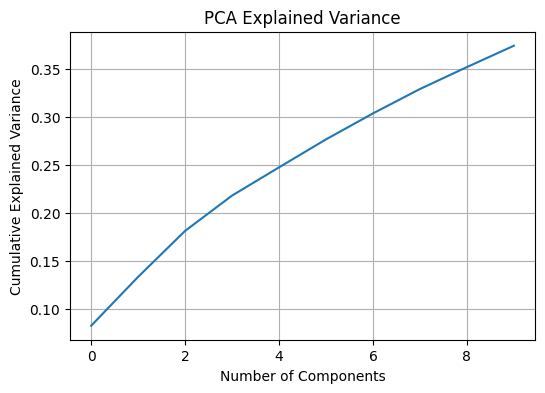

In [17]:
### PCA explained variance plot

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

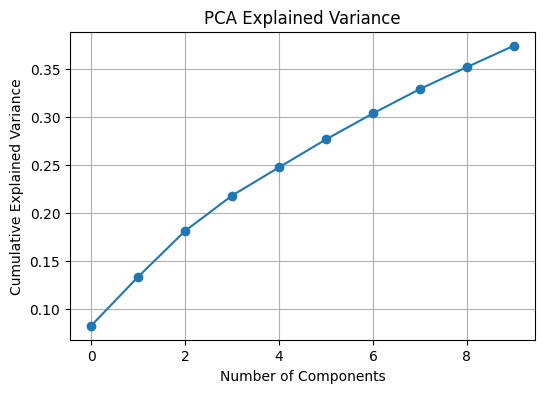

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [18]:
### confusion matrices for all models

from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf
}

for name, preds in models.items():
    print("\n=== {} ===".format(name))
    cm = confusion_matrix(y_test, preds)
    print(cm)


=== Logistic Regression ===
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 2 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [19]:
### random forest feature importances for PCA components

importances = rf.feature_importances_
for i, imp in enumerate(importances):
    print(f"PCA Component {i+1}: {imp:.4f}")

PCA Component 1: 0.0523
PCA Component 2: 0.0876
PCA Component 3: 0.1243
PCA Component 4: 0.1075
PCA Component 5: 0.1241
PCA Component 6: 0.0960
PCA Component 7: 0.1018
PCA Component 8: 0.1032
PCA Component 9: 0.0950
PCA Component 10: 0.1081


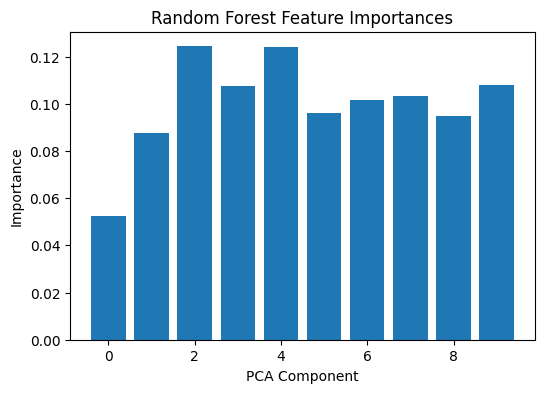

In [20]:
plt.figure(figsize=(6,4))
plt.bar(range(len(importances)), importances)
plt.xlabel("PCA Component")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.show()

In [21]:
### CLASSIFICATION MODELS (predict person labels)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, multi_class='multinomial', C=0.3, solver='lbfgs')
log_reg.fit(X_train_pca, y_train)
pred_lr = log_reg.predict(X_test_pca)
acc_lr = accuracy_score(y_test, pred_lr)
cv_lr = cross_val_score(log_reg, X_train_pca, y_train, cv=3)

# Ridge Classifier
ridge_clf = RidgeClassifier(alpha=1.0)
ridge_clf.fit(X_train_pca, y_train)
pred_ridge_clf = ridge_clf.predict(X_test_pca)
acc_ridge_clf = accuracy_score(y_test, pred_ridge_clf)
cv_ridge_clf = cross_val_score(ridge_clf, X_train_pca, y_train, cv=3)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_pca, y_train)
pred_dt = dt.predict(X_test_pca)
acc_dt = accuracy_score(y_test, pred_dt)
cv_dt = cross_val_score(dt, X_train_pca, y_train, cv=3)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_pca, y_train)
pred_rf = rf.predict(X_test_pca)
acc_rf = accuracy_score(y_test, pred_rf)
cv_rf = cross_val_score(rf, X_train_pca, y_train, cv=3)

In [22]:
import pandas as pd

class_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Ridge Classifier", "Decision Tree", "Random Forest"],
    "Test Accuracy": [acc_lr, acc_ridge_clf, acc_dt, acc_rf],
    "CV Accuracy": [np.mean(cv_lr), np.mean(cv_ridge_clf), np.mean(cv_dt), np.mean(cv_rf)]
})

class_results

,Model,Test Accuracy,CV Accuracy
0,Logistic Regression,0.425,0.549383
1,Ridge Classifier,0.350,0.412299
2,Decision Tree,0.250,0.306080
3,Random Forest,0.375,0.474493


# PCA and Classification Model Analysis

## 1. PCA Explained Variance
- The cumulative explained variance plot shows how much of the total variance is captured by the first N principal components.
- In this case, the first 10 components capture ~37.4% of the total variance in the neuron activation data.
- **Interpretation:** PCA reduces the dimensionality while keeping the most important patterns. While 37% is moderate, it may still leave some information out, which affects classification performance.

## 2. Confusion Matrices
- Confusion matrices for Logistic Regression, Decision Tree, and Random Forest were generated on the test set.
- **Logistic Regression:** Some classes are predicted well, but many are completely missed, reflecting moderate accuracy (~42.5%).
- **Decision Tree:** Many classes are misclassified, resulting in very low accuracy (~25%), likely due to small sample sizes per class and high variance.
- **Random Forest:** Performs better than a single tree (~37.5% accuracy) due to averaging predictions over multiple trees, but still struggles on small/noisy classes.

**Interpretation:**  
- Confusion matrices reveal which classes are hardest to predict. Many diagonal zeros indicate underrepresented or overlapping class patterns in PCA space.

## 3. Random Forest Feature Importances
- The importance of each PCA component in the Random Forest classifier is as follows (top contributors highlighted):
    - PCA 3: 0.124  
    - PCA 5: 0.124  
    - PCA 4: 0.107  
    - PCA 10: 0.108  
- **Interpretation:** Some PCA components contribute more to classification than others. Components with higher importance capture the neural activity patterns most relevant to distinguishing between people.

## 4. Classification Model Performance Summary

| Model                  | Test Accuracy | CV Accuracy |
|------------------------|---------------|-------------|
| Logistic Regression     | 0.425         | 0.549      |
| Ridge Classifier        | 0.350         | 0.412      |
| Decision Tree           | 0.250         | 0.306      |
| Random Forest           | 0.375         | 0.474      |

**Interpretation:**
1. **Logistic Regression** performs best overall on test and CV accuracy. It models linear boundaries between PCA features for class separation.
2. **Ridge Classifier** is linear but regularized. It underperforms compared to Logistic Regression, possibly due to the weak linear separability of the data.
3. **Decision Tree** performs poorly because trees overfit small, noisy datasets and the PCA features may not capture all class distinctions.
4. **Random Forest** improves over a single tree by reducing variance and stabilizing predictions. Still, performance is limited by small class sizes and overlapping PCA patterns.

## 5. Key Insights
- **PCA captures only part of the variance (~37%),** which limits model performance.
- **Small and uneven class sizes** reduce classification accuracy.
- **Linear models (Logistic, Ridge)** handle the dimensionality better than tree-based models given the reduced PCA features.
- **Random Forest** shows the benefit of ensemble learning, but cannot fully overcome overlapping or noisy patterns in the PCA space.

## 6. Recommendations
- **Best model for this dataset:** Logistic Regression for classification, due to highest test and CV accuracy.
- **Next steps:** Consider more PCA components to capture additional variance or alternative dimensionality reduction methods, and explore techniques to handle class imbalance.